# Customer Churn Prediction

Notebook for the Telco Customer Churn project.

## Insights

Add feature importance, business insights, and model export notes here.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

possible_paths = [Path('data/telco_churn.csv'), Path('../data/telco_churn.csv')]
for candidate_path in possible_paths:
    if candidate_path.exists():
        DATA_PATH = candidate_path
        break
else:
    raise FileNotFoundError('Could not find data/telco_churn.csv in the workspace or notebook parent folder.')

df = pd.read_csv(DATA_PATH)

print(f'Loaded from: {DATA_PATH}')
df.shape, df.head()

Loaded from: ..\data\telco_churn.csv


((7043, 21),
    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
 0  7590-VHVEG  Female              0     Yes         No       1           No   
 1  5575-GNVDE    Male              0      No         No      34          Yes   
 2  3668-QPYBK    Male              0      No         No       2          Yes   
 3  7795-CFOCW    Male              0      No         No      45           No   
 4  9237-HQITU  Female              0      No         No       2          Yes   
 
       MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
 0  No phone service             DSL             No  ...               No   
 1                No             DSL            Yes  ...              Yes   
 2                No             DSL            Yes  ...               No   
 3  No phone service             DSL            Yes  ...              Yes   
 4                No     Fiber optic             No  ...               No   
 
   TechSupport StreamingTV Streamin

In [ ]:
#data audit
summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().sum() / len(df) * 100).round(2),
})

blank_total_charges = (df['TotalCharges'].astype(str).str.strip() == '').sum()
print(f'Rows: {len(df)}')
print(f'Columns: {df.shape[1]}')
print(f'Blank TotalCharges values: {blank_total_charges}')
summary.sort_values('missing_count', ascending=False)

Rows: 7043
Columns: 21
Blank TotalCharges values: 11


,dtype,missing_count,missing_pct
customerID,str,0,0.0
gender,str,0,0.0
SeniorCitizen,int64,0,0.0
Partner,str,0,0.0
Dependents,str,0,0.0
tenure,int64,0,0.0
PhoneService,str,0,0.0
MultipleLines,str,0,0.0
InternetService,str,0,0.0
OnlineSecurity,str,0,0.0


In [3]:
# Target balance
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True).mul(100).round(2)

pd.DataFrame({'count': churn_counts, 'pct': churn_pct})

,count,pct
Churn,,
No,5174,73.46
Yes,1869,26.54


C:\Users\trish\AppData\Local\Temp\ipykernel_23248\636096636.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Contract', order=df['Contract'].value_counts().index, ax=axes[2], palette='Set2')


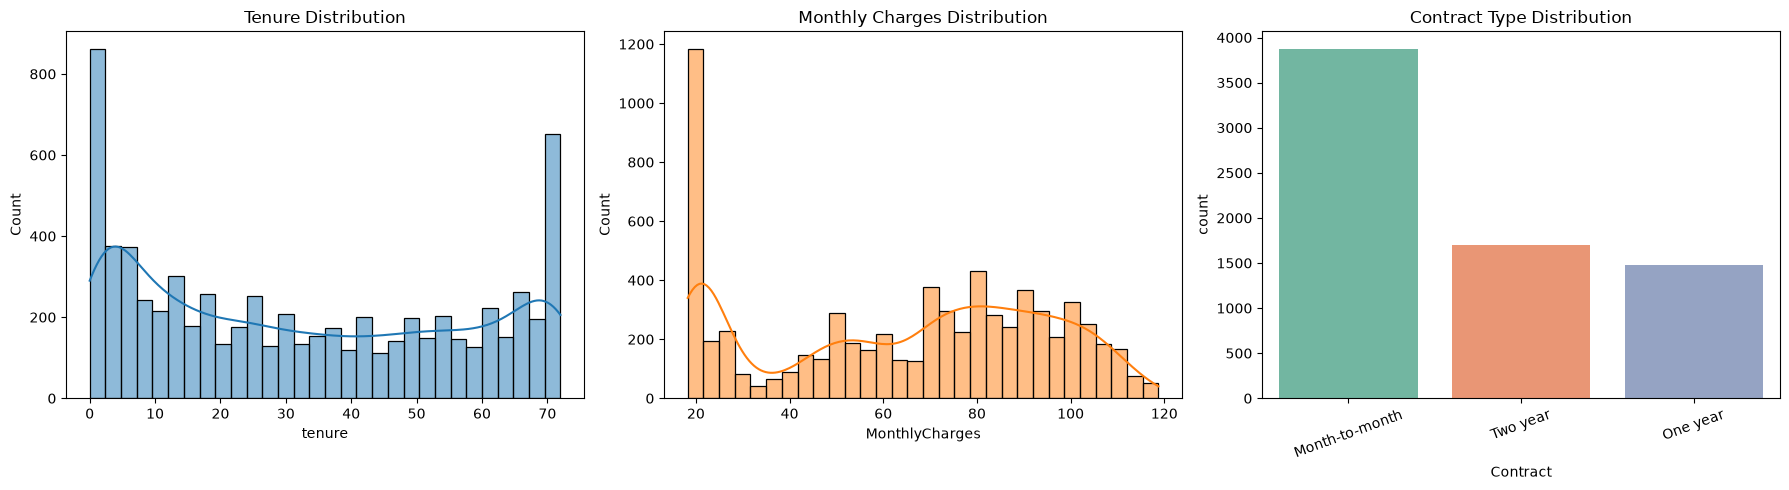

In [4]:
# Initial univariate views
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['tenure'], bins=30, kde=True, ax=axes[0], color='#1f77b4')
axes[0].set_title('Tenure Distribution')

sns.histplot(df['MonthlyCharges'], bins=30, kde=True, ax=axes[1], color='#ff7f0e')
axes[1].set_title('Monthly Charges Distribution')

sns.countplot(data=df, x='Contract', order=df['Contract'].value_counts().index, ax=axes[2], color='#55a868')
axes[2].set_title('Contract Type Distribution')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()

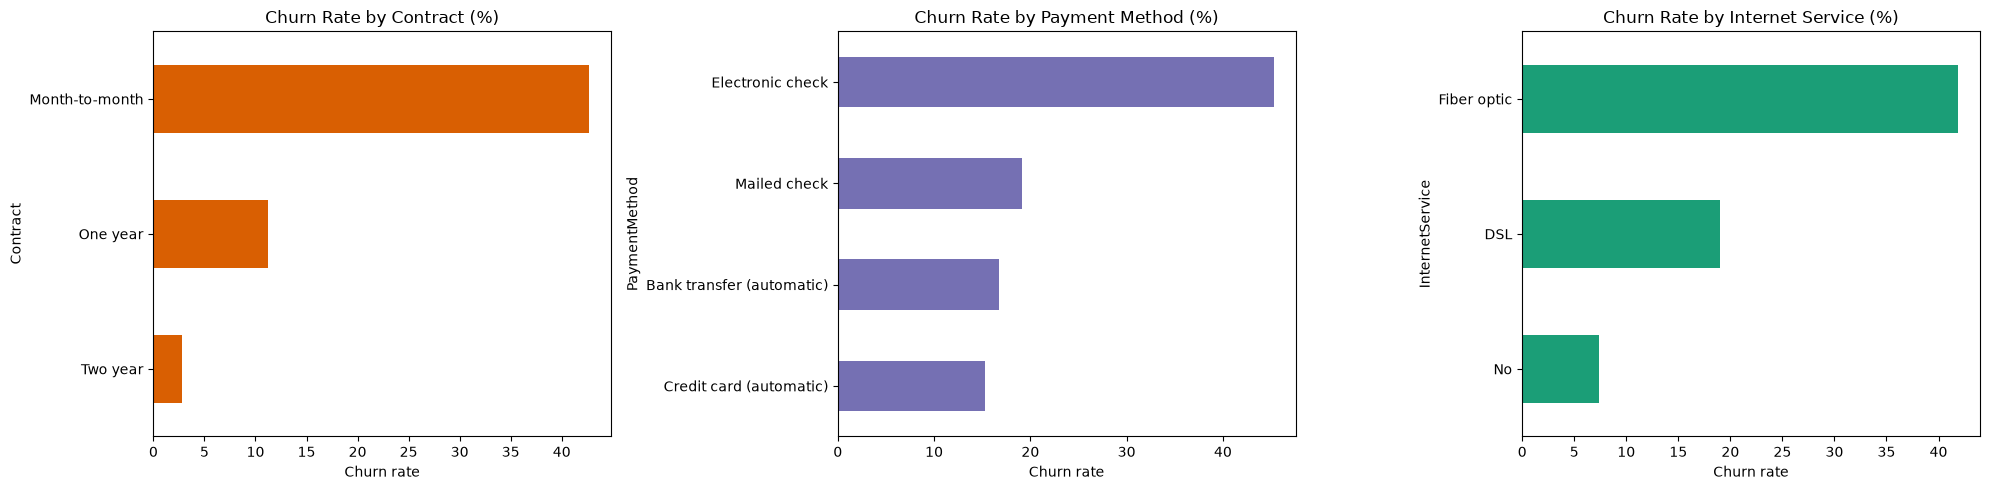

In [5]:
# Bivariate analysis: churn rate by contract, payment method, and internet service
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index').mul(100)
contract_churn['Yes'].sort_values().plot(kind='barh', ax=axes[0], color='#d95f02')
axes[0].set_title('Churn Rate by Contract (%)')
axes[0].set_xlabel('Churn rate')

payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index').mul(100)
payment_churn['Yes'].sort_values().plot(kind='barh', ax=axes[1], color='#7570b3')
axes[1].set_title('Churn Rate by Payment Method (%)')
axes[1].set_xlabel('Churn rate')

internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index').mul(100)
internet_churn['Yes'].sort_values().plot(kind='barh', ax=axes[2], color='#1b9e77')
axes[2].set_title('Churn Rate by Internet Service (%)')
axes[2].set_xlabel('Churn rate')

plt.tight_layout()

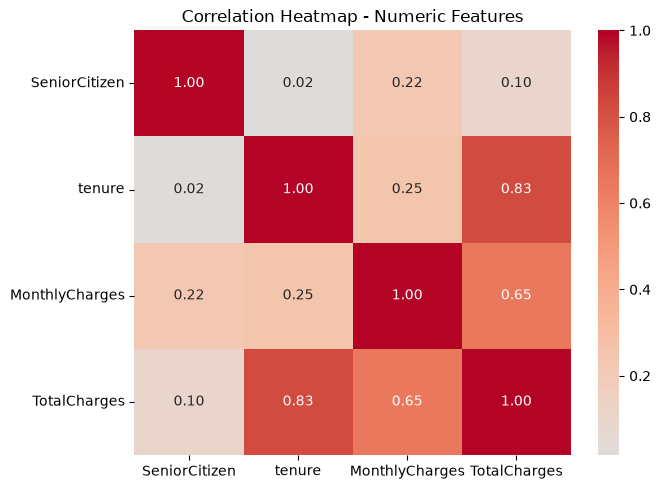

In [6]:
# Correlation heatmap for numeric features
eda_df = df.copy()
eda_df['TotalCharges'] = pd.to_numeric(eda_df['TotalCharges'], errors='coerce')

numeric_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(7, 5))
sns.heatmap(eda_df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap - Numeric Features')
plt.tight_layout()

## Phase 2 Discoveries

- The dataset is imbalanced: non-churners are the majority, so recall will matter later.
- Month-to-month contracts appear to carry the highest churn risk, while longer contracts are more stable.
- Electronic check customers and fiber internet customers look like higher-risk segments worth closer inspection.
- TotalCharges contains blank values that will need cleaning before modeling.